In [ ]:
import json
import re
import base64
import requests
from io import BytesIO
from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, confusion_matrix, classification_report

# ==========================================
# LOCAL OLLAMA CONFIGURATION
# ==========================================
OLLAMA_URL = "http://localhost:11434/api/generate"
MODEL_NAME = "gemma4:4b"  # Update if your exact tag differs (e.g., gemma-4:4b)

example_dir = Path("./datasets/crc-pathassists-patches/patches")
test_cases_path = "./datasets/split-test/split_test.json"

SURVIVAL_PROMPT = """<|think|>You are a computational pathologist performing morphological prognostication on colorectal cancer resection specimens. You will receive H&E patch images only — no staging or molecular data is provided.

Systematically assess:
1. Glandular architecture (% formation -> grade)
2. Tumour-stroma ratio (>50% stroma = poor)
3. Tumour budding at invasive front (Bd1/2/3)
4. TIL density at tumour-stroma border (High TILs -> better prognosis, often MSI-H)
5. Necrosis presence
6. Mucinous or signet ring features
7. Nuclear pleomorphism and mitotic activity

Based ONLY on these visual features, predict whether this patient survived 5 years.
Return JSON only:
{
  "survival_prediction": "Good" or "Poor",
  "confidence": "High", "Moderate", or "Low",
  "til_density": "High", "Moderate", or "Low",
  "stromal_ratio": "Stroma-rich" or "Stroma-poor",
  "tumour_budding": "Bd1", "Bd2", "Bd3", or "Cannot determine",
  "necrosis": true or false,
  "key_reasoning": "2-3 sentences explaining the prediction"
}
Return JSON only. No other text."""

# Example JSONs
good_json = '{"survival_prediction": "Good", "confidence": "High", "til_density": "High", "stromal_ratio": "Stroma-poor", "tumour_budding": "Bd1", "necrosis": false, "key_reasoning": "Well-differentiated glandular architecture with high TILs and minimal stroma."}'
poor_json = '{"survival_prediction": "Poor", "confidence": "High", "til_density": "Low", "stromal_ratio": "Stroma-rich", "tumour_budding": "Bd3", "necrosis": true, "key_reasoning": "Poorly formed glands with high stromal infiltration and visible tumor budding at the invasive front."}'

# ==========================================
# HELPER: IMAGE TO BASE64 FOR OLLAMA
# ==========================================
def process_image_to_base64(img_path):
    """Loads, resizes to 336px to save VRAM, and converts to base64."""
    try:
        img = Image.open(img_path).convert("RGB")
        img = img.resize((336, 336), Image.Resampling.LANCZOS) # 6GB VRAM limit workaround
        buffered = BytesIO()
        img.save(buffered, format="JPEG")
        return base64.b64encode(buffered.getvalue()).decode("utf-8")
    except Exception as e:
        print(f"Error processing image {img_path}: {e}")
        return None

# Load Example Images and Convert to Base64
good_imgs_b64 = [
    process_image_to_base64(example_dir / "SR386_40X_HE_T014_01/p00.png"),
    process_image_to_base64(example_dir / "SR386_40X_HE_T014_01/p01.png")
]
poor_imgs_b64 = [
    process_image_to_base64(example_dir / "SR386_40X_HE_T003_01/p00.png"),
    process_image_to_base64(example_dir / "SR386_40X_HE_T003_01/p01.png")
]

# Filter out any None values if files were missing
good_imgs_b64 = [img for img in good_imgs_b64 if img is not None]
poor_imgs_b64 = [img for img in poor_imgs_b64 if img is not None]

# ==========================================
# LOCAL INFERENCE FUNCTION
# ==========================================
def run_4b_local_ollama(case: dict, patch_dir=example_dir):
    target_imgs_b64 = []
    
    # Strictly limit to 2 patches to prevent OOM on 6GB VRAM
    for patch_path in case.get("patches", [])[:2]: 
        clean_path = patch_path.replace("\\", "/").split("patches/")[-1]
        full_path = Path(patch_dir) / clean_path 
        if full_path.exists():
            b64_img = process_image_to_base64(full_path)
            if b64_img:
                target_imgs_b64.append(b64_img)
            
    if not target_imgs_b64:
         return {"error": "No images found locally"}

    # Combine all images into one list for the Ollama payload
    all_images = good_imgs_b64 + poor_imgs_b64 + target_imgs_b64

    text_prompt = f"""{SURVIVAL_PROMPT}

--- EXAMPLE 1: GOOD SURVIVAL ---
{good_json}

--- EXAMPLE 2: POOR SURVIVAL ---
{poor_json}

--- NOW PREDICT THIS NEW CASE ---
CASE: {case['case_id']}
Specimen: Colorectal cancer resection, H&E stained
Patches provided: {len(target_imgs_b64)}

Predict 5-year survival from morphology alone. Return JSON only."""

    # Construct the strictly constrained payload for 6GB VRAM
    payload = {
        "model": MODEL_NAME,
        "prompt": text_prompt,
        "images": all_images,
        "stream": False,
        "format": "json", # Forces Ollama to output valid JSON
        "keep_alive": 0,  # CRITICAL: Flushes VRAM immediately after generation
        "options": {
            "num_predict": 512,
            "temperature": 0.1,
            "num_ctx": 4096  # Lock context window to save VRAM
        }
    }

    try:
        response = requests.post(OLLAMA_URL, json=payload, timeout=120)
        response.raise_for_status()
        result = response.json()
        
        text = result.get("response", "").strip()
        match = re.search(r'\{[\s\S]+?\}', text)
        if match:
            return json.loads(match.group())
        return {"error": "parse failed", "raw": text}
        
    except requests.exceptions.ConnectionError:
        return {"error": "Ollama connection refused. Is Ollama running?"}
    except Exception as e:
        return {"error": str(e)}

# ==========================================
# EVALUATION LOOP
# ==========================================
try:
    with open(test_cases_path, 'r') as f:
        test_cases = json.load(f)
except FileNotFoundError:
    print(f"Could not find test cases at {test_cases_path}. Please update paths for your PC.")
    test_cases = []

if test_cases:
    y_true, y_pred, results = [], [], []

    print(f"Starting local evaluation on {MODEL_NAME}...")
    for case in tqdm(test_cases):
        pred = run_4b_local_ollama(case)
        
        if "error" in pred:
            print(f"Failed: {case['case_id']} - {pred.get('raw', pred.get('error'))}")
            continue
            
        gt = 1 if case.get("survival_label", "").lower() == "good" else 0
        p  = 1 if pred.get("survival_prediction","").lower() == "good" else 0
        
        y_true.append(gt)
        y_pred.append(p)
        results.append({
            "case_id":    case["case_id"],
            "gt":         case.get("survival_label"),
            "pred":       pred.get("survival_prediction",""),
            "confidence": pred.get("confidence",""),
            "correct":    gt == p,
            "reasoning":  pred.get("key_reasoning",""),
            "til":        pred.get("til_density",""),
            "stroma":     pred.get("stromal_ratio",""),
            "budding":    pred.get("tumour_budding","")
        })

    if y_true:
        # Metrics
        auc = roc_auc_score(y_true, y_pred)
        acc = sum(y_true[i]==y_pred[i] for i in range(len(y_true))) / len(y_true)
        cm  = confusion_matrix(y_true, y_pred)

        print(f"\nCases evaluated locally: {len(y_true)}")
        print(f"Accuracy: {acc*100:.1f}%")
        print(f"AUC: {auc:.3f}")
        print(f"\nConfusion matrix:\n{cm}")
        print(classification_report(y_true, y_pred, target_names=["Poor","Good"], zero_division=0))

        # Save Output
        with open("survival_local_results.json", "w") as f:
            json.dump({
                "model": MODEL_NAME,
                "metrics": {"accuracy": acc, "auc": auc, "n": len(y_true)},
                "confusion_matrix": cm.tolist(),
                "cases": results
            }, f, indent=2)
            
        print("\nResults saved to survival_local_results.json")

100%|██████████| 57/57 [28:45<00:00, 30.27s/it]


Cases evaluated: 57
Accuracy: 40.4%
AUC: 0.500

Confusion matrix:
[[15  4]
 [30  8]]
              precision    recall  f1-score   support

        Poor       0.33      0.79      0.47        19
        Good       0.67      0.21      0.32        38

    accuracy                           0.40        57
   macro avg       0.50      0.50      0.39        57
weighted avg       0.56      0.40      0.37        57


Results saved to survival_27b_results.json in the Kaggle working directory.


In [ ]:
import pandas as pd
import numpy as np
import json
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix, roc_curve

# 1. Load the results and map features (Same as before)
with open("./output/survival_27b_results.json", "r") as f:
    data = json.load(f)
df = pd.DataFrame(data["cases"])

df["til_score"] = df.get("til", pd.Series(dtype=object)).map({"Low": 0, "Moderate": 1, "High": 2}).fillna(1)
df["stroma_score"] = df.get("stroma", pd.Series(dtype=object)).map({"Stroma-poor": 0, "Stroma-rich": 1}).fillna(0)
df["budding_score"] = df.get("budding", pd.Series(dtype=object)).map({"Bd1": 1, "Bd2": 2, "Bd3": 3, "Cannot determine": 0}).fillna(0)

def parse_necrosis(val):
    if pd.isna(val): return 0
    if str(val).lower() == 'true': return 1
    return 0
df["necrosis_score"] = df.get("necrosis", pd.Series([False]*len(df))).apply(parse_necrosis)

X = df[["til_score", "stroma_score", "budding_score", "necrosis_score"]]
y = df["gt"].str.lower().map({"good": 1, "poor": 0})

# 2. Train LR
lr_model = LogisticRegression(class_weight="balanced", C=0.5, penalty='l2', random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_proba = cross_val_predict(lr_model, X, y, cv=cv, method="predict_proba")[:, 1]

# 3. THE FIX: Youden's J Statistic Threshold Tuning
fpr, tpr, thresholds = roc_curve(y, y_pred_proba)
J = tpr - fpr # Youden's J formula
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Probability Threshold (Youden's J): {optimal_threshold:.3f}")

y_pred_tuned = (y_pred_proba >= optimal_threshold).astype(int)

# 4. Final Metrics
tuned_acc = accuracy_score(y, y_pred_tuned)
lr_auc = roc_auc_score(y, y_pred_proba)

print(f"\n--- BALANCED LOGISTIC REGRESSION ---")
print(f"Accuracy: {tuned_acc*100:.1f}%")
print(f"AUC: {lr_auc:.3f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred_tuned))
print("\nClassification Report:")
print(classification_report(y, y_pred_tuned, target_names=["Poor", "Good"]))

Optimal Probability Threshold (Youden's J): 0.496

--- BALANCED LOGISTIC REGRESSION ---
Accuracy: 61.4%
AUC: 0.605

Confusion Matrix:
[[13  6]
 [16 22]]

Classification Report:
              precision    recall  f1-score   support

        Poor       0.45      0.68      0.54        19
        Good       0.79      0.58      0.67        38

    accuracy                           0.61        57
   macro avg       0.62      0.63      0.60        57
weighted avg       0.67      0.61      0.62        57



In [7]:
import pickle
lr_model.fit(X, y)  # fit on full data after CV evaluation
pickle.dump(lr_model, open("lr_survival_model.pkl","wb"))
print("Model saved.")

Model saved.


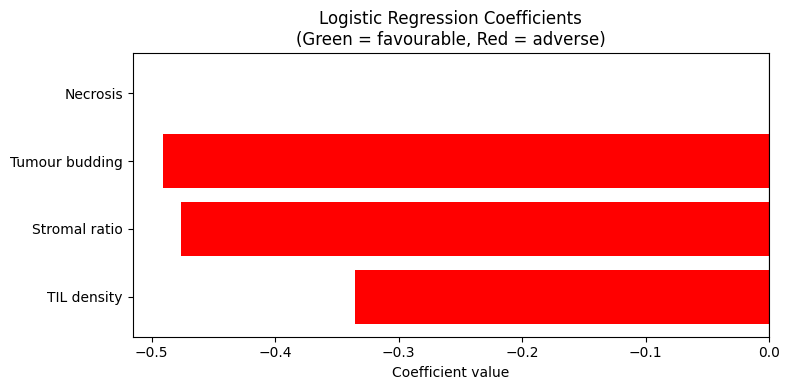

In [8]:
import matplotlib.pyplot as plt
import numpy as np

features = ["TIL density", "Stromal ratio", "Tumour budding", "Necrosis"]
coefs    = lr_model.coef_[0]

colours = ["green" if c > 0 else "red" for c in coefs]
plt.figure(figsize=(8,4))
plt.barh(features, coefs, color=colours)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Logistic Regression Coefficients\n(Green = favourable, Red = adverse)")
plt.xlabel("Coefficient value")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()